# Plot Figure S8B: Spatial Regrowth Gradient Comparison

## Overview
This notebook generates Figure S8B showing regrowth probability as a function of distance from P. aeruginosa, comparing:
- AB homogeneous (wild-type)
- AB gradient

## Analysis Workflow
1. **Load Data**: Import per-chamber regrowth fractions from both conditions
2. **Calculate Statistics**: Compute mean ± std for each spatial bin
3. **Generate Plot**: Create line plot with shaded error regions

## Output
- `S8B_ab_gradient_yaxis.pdf`: Publication-ready figure showing spatial gradients

In [1]:
# Data analysis and visualization packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

# Set publication-quality style
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 8
matplotlib.rcParams['pdf.fonttype'] = 42  # Editable text in PDF
matplotlib.rcParams['ps.fonttype'] = 42

pnas_fontsize = 8

# Step 1: Load and Process Data

## Objective
Load per-chamber regrowth data and calculate statistics for each spatial bin.

## Method
- Load per-chamber data for both conditions
- Filter for y-axis (distance from PA)
- Calculate mean and standard deviation across chambers for each bin

In [2]:
# Load per-chamber data
chamber_wt = pd.read_csv('../../Figure1/1E/figure_code/1_regrowth_fractions_wt_per_chamber.csv')
chamber_ab_gradient = pd.read_csv('1_regrowth_fractions_ab_gradient_per_chamber.csv')


# Helper function to extract statistics
def extract_stats(df, axis='y'):
    """
    Extract mean and std from per-chamber data for specified axis.
    
    Parameters
    ----------
    df : DataFrame
        Per-chamber regrowth fraction data
    axis : str
        Which axis to analyze ('x' or 'y')
    
    Returns
    -------
    tuple
        (mean_values, std_values, bin_positions)
    """
    df_axis = df[df['axis'] == axis].copy().sort_values('bin_left')
    
    # Compute statistics from raw chamber data
    stats = df_axis.groupby('bin_left')['regrowth_fraction'].agg(
        mean_regrowth_fraction='mean',
        std_regrowth_fraction=lambda x: np.std(x, ddof=1)
    ).reset_index()
    
    return (
        stats['mean_regrowth_fraction'].values,
        stats['std_regrowth_fraction'].values,
        stats['bin_left'].values
    )

# Extract statistics for y-axis
wt_mean, wt_std, wt_x = extract_stats(chamber_wt)
gradient_mean, gradient_std, gradient_x = extract_stats(chamber_ab_gradient)

print(f"AB homogeneous: {len(wt_x)} bins")
print(f"AB gradient: {len(gradient_x)} bins")

AB homogeneous: 10 bins
AB gradient: 10 bins


# Step 2: Generate Figure S8B

## Visualization
- Line plot showing mean regrowth fraction vs distance
- Shaded region representing ± 1 standard deviation
- AB homogeneous in yellow (#ffcc66)
- AB gradient in grey
- PNAS-style formatting (minimal spines, subtle grid)

✅ Figure saved: S8B_ab_gradient_yaxis.pdf


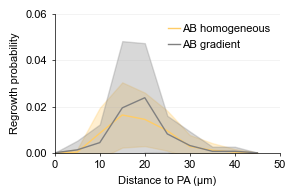

In [3]:
# Helper function for plotting
def plot_with_shade(ax, mean, std, x, label, color):
    """
    Plot mean ± std as line with shaded error region.
    
    Parameters
    ----------
    ax : matplotlib axis
        Axis to plot on
    mean : array
        Mean values
    std : array
        Standard deviation values
    x : array
        X-axis positions
    label : str
        Legend label
    color : str
        Line and shade color
    
    Returns
    -------
    line
        Matplotlib line object
    """
    line = ax.plot(x, mean, label=label, color=color, linewidth=1)
    ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.3)
    return line[0]

# Create figure
fig, ax = plt.subplots(figsize=(3, 2))

# Plot both datasets
line_wt = plot_with_shade(ax, wt_mean, wt_std, wt_x, 
                          'AB homogeneous', '#ffcc66')
line_gradient = plot_with_shade(ax, gradient_mean, gradient_std, gradient_x, 
                                'AB gradient', 'grey')

# Labels and formatting
ax.set_xlabel('Distance to PA (µm)', fontsize=pnas_fontsize)
ax.set_ylabel('Regrowth probability', fontsize=pnas_fontsize)

# Set limits and ticks
ax.set_xlim(0, 50)
ax.set_ylim(0, 0.06)
ax.set_xticks([0, 10, 20, 30, 40, 50])
ax.set_yticks([0.00, 0.02, 0.04, 0.06])

# Apply PNAS-style formatting
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
ax.tick_params(axis='both', which='major', width=0.5, length=2, 
               labelsize=pnas_fontsize)
ax.grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.5)

# Add legend
ax.legend(frameon=False, fontsize=pnas_fontsize, loc='upper right',
          handlelength=1, handletextpad=0.2)

plt.tight_layout()

# Save figure
output_pdf = 'S8B_ab_gradient_yaxis.pdf'
plt.savefig(output_pdf, dpi=300, bbox_inches='tight')
print(f"✅ Figure saved: {output_pdf}")
plt.show()